In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# A made-up samples
X = np.array([[18, 10, 0],
              [16, 7, 1],
              [26, 6, 0],
              [14, 10, 1],
              [11, 10, 1],
              [21, 5, 0],
              [13, 10, 0],
              [10, 8, 0],
              [10, 10, 0],
              [9, 10, 1],
              [9, 8, 1],
              [17, 5, 0],
              [16, 6, 0],
              [16, 4, 0],
              [40, 10, 0],
              [35, 9, 1],
              ],
             )

y = np.array([50000, 12000, 23000, 45000, 68000, 20000, 88000,
              90000, 150000, 130000, 85000, 15000, 23000, 11000, 35000, 15000]) / 10000

X_train_, X_cv_, y_train_, y_cv_ = train_test_split(X, y, test_size=0.3, random_state=102)

scaler = StandardScaler()

X_train = np.tile(X_train_, (1000, 1))
y_train = np.tile(y_train_, 1000)
X_train_scaled = scaler.fit_transform(X_train)

X_cv = np.tile(X_cv_, (1000, 1))
y_cv = np.tile(y_cv_, 1000)
X_cv_scaled = scaler.transform(X_cv)

X_scaled = scaler.transform(X)

In [3]:
def fx(X, w, b):
    return np.dot(X, w) + b

In [4]:
def compute_cost(X, y, w, b, lambda_=0):
    m = len(X_train_scaled)
    f_wb = fx(X, w, b)
    error = f_wb - y
    total_loss = 1 / 2 * m * np.sum(error ** 2)
    reg = lambda_ / (2 * m) * np.sum(w ** 2)
    cost = total_loss + reg
    return cost

In [5]:
def compute_gradient(X, y, w, b, lambda_=0):
    m = X.shape[0]
    f_wb = fx(X, w, b)
    dj_dw = np.sum((f_wb - y).reshape(-1, 1) * X, axis=0) / m
    dj_dw += lambda_ / m * w     # Regularization term
    dj_db = np.sum((f_wb - y)) / m

    return dj_dw, dj_db

In [6]:
def compute_gradient_descent(X, y, alpha=4e-3, n_iter=5000, lambda_=0):
    w = np.ones_like(X_train_scaled[0], dtype=float)
    b = 0.0

    for _ in range(n_iter):
        dj_dw, dj_db = compute_gradient(X, y, w, b, lambda_)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

    return w, b

In [7]:
lambdas = []
costs_cv = []
costs_train = []
base = 2
weights = []

for i in range(20):
    lambda_ = base ** i
    w, b = compute_gradient_descent(X_train_scaled, y_train, lambda_=lambda_)
    cost_cv = compute_cost(X_cv_scaled, y_cv, w, b, lambda_)
    cost_train = compute_cost(X_train_scaled, y_train, w, b, lambda_)
    
    weights.append((w, b))
    lambdas.append(lambda_)
    costs_cv.append(cost_cv)
    costs_train.append(cost_train)

    print(f"Lambda: {lambda_}, cost_cv: {cost_cv}, cost_train: {cost_train}")

i_min_cost = np.argmin(costs_cv)
lambda_min_cost = base ** i_min_cost
final_w, final_b = weights[i_min_cost]

print("The lambda with the most min cost:", lambda_min_cost)


Lambda: 1, cost_cv: 42086367.229607865, cost_train: 387733074.7641691
Lambda: 2, cost_cv: 42075671.13328399, cost_train: 387733102.7148863
Lambda: 4, cost_cv: 42054306.31005161, cost_train: 387733212.5567737
Lambda: 8, cost_cv: 42011685.95839399, cost_train: 387733647.6173225
Lambda: 16, cost_cv: 41926880.976528384, cost_train: 387735376.1750486
Lambda: 32, cost_cv: 41759002.31630998, cost_train: 387742242.62951624
Lambda: 64, cost_cv: 41430078.81370465, cost_train: 387769420.10349756
Lambda: 128, cost_cv: 40798855.55482414, cost_train: 387876049.51916736
Lambda: 256, cost_cv: 39637509.514538944, cost_train: 388286962.9465671
Lambda: 512, cost_cv: 37680346.96619078, cost_train: 389816396.09653425
Lambda: 1024, cost_cv: 34973133.7090479, cost_train: 395155214.45427626
Lambda: 2048, cost_cv: 32964565.14241366, cost_train: 411842950.5482582
Lambda: 4096, cost_cv: 36394307.31980451, cost_train: 455798979.15108883
Lambda: 8192, cost_cv: 53900130.1360089, cost_train: 547587615.329635
Lambda:

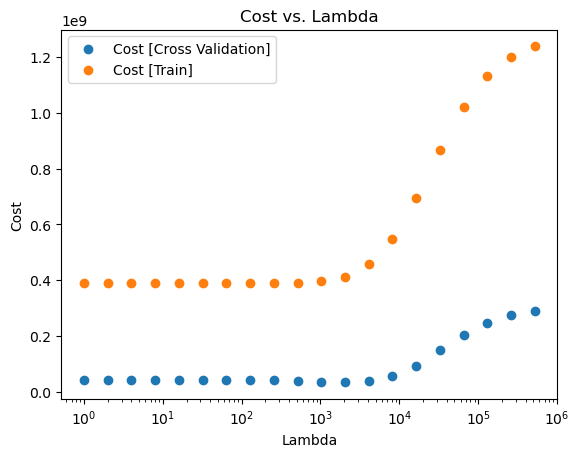

In [8]:
fig, ax = plt.subplots()
ax.scatter(lambdas, costs_cv, label="Cost [Cross Validation]")
ax.scatter(lambdas, costs_train, label="Cost [Train]")
ax.set_title("Cost vs. Lambda")
ax.set_xlabel("Lambda")
ax.set_ylabel("Cost")
ax.legend()
ax.set_xscale('log')
plt.show()

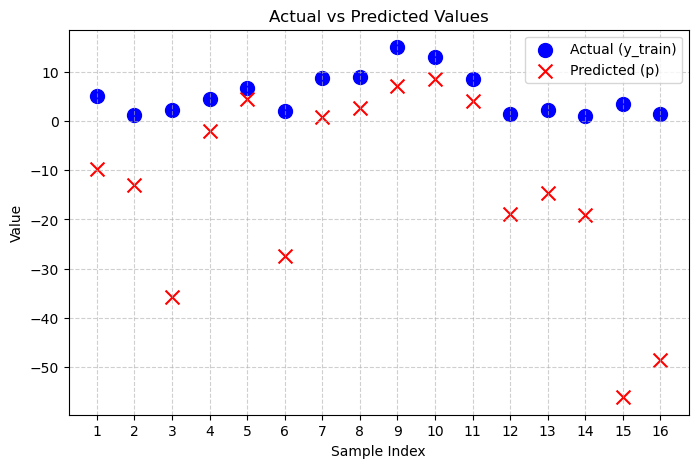

In [9]:
predictions = []
actual_values = []

for i, x in enumerate(X):
    pred = fx(x, final_w, final_b)
    predictions.append(pred)
    actual_values.append(y[i])

plt.figure(figsize=(8, 5))
sample_indices = range(1, len(X) + 1)

plt.scatter(sample_indices, actual_values, color='blue',
            label='Actual (y_train)', marker='o', s=100)
plt.scatter(sample_indices, predictions, color='red',
            label='Predicted (p)', marker='x', s=100)

plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.xticks(sample_indices)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

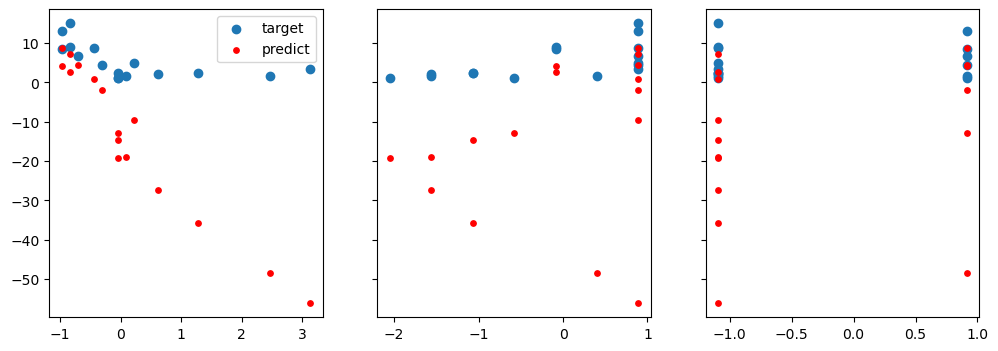

In [10]:
plt.close()
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_scaled[:, i], y, label='target')
    ax[i].scatter(X_scaled[:, i], predictions, color='r', label='predict', marker='.', s=60)
ax[0].legend()